In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('../data/ames_cleaned.csv', keep_default_na=False, na_values=[''])
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,No Alley Access,IR1,Lvl,...,0,No Pool,No Fence,None,0,5,2010.0,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,No Alley Access,Reg,Lvl,...,0,No Pool,MnPrv,None,0,6,2010.0,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,No Alley Access,IR1,Lvl,...,0,No Pool,No Fence,Gar2,12500,6,2010.0,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,No Alley Access,Reg,Lvl,...,0,No Pool,No Fence,None,0,4,2010.0,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,No Alley Access,IR1,Lvl,...,0,No Pool,MnPrv,None,0,3,2010.0,WD,Normal,189900


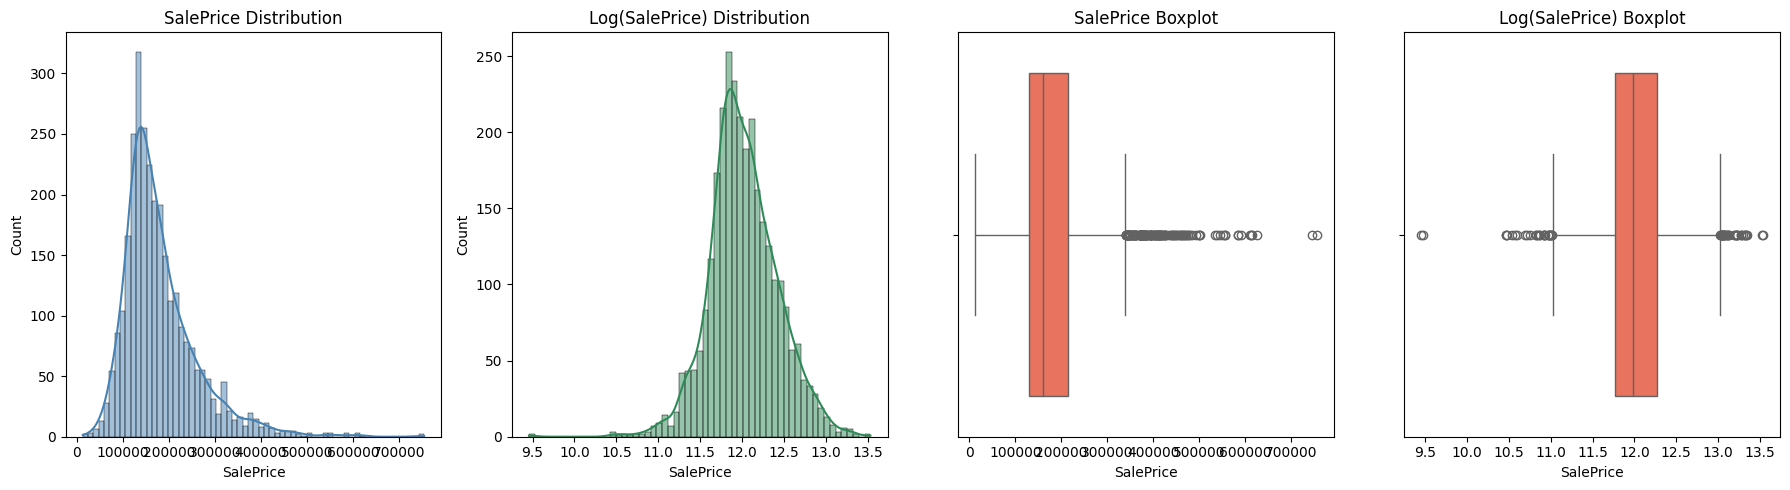

In [3]:
figs, axes = plt.subplots(1, 4, figsize=(18, 5))

# Distribution
sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('SalePrice Distribution')

# Log-transformed distribution
sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Log(SalePrice) Distribution')

# Log(SalePrice) Boxplot with outliers
sns.boxplot(x=df['SalePrice'], ax=axes[2], color='tomato')
axes[2].set_title('SalePrice Boxplot')

# Log(SalePrice) Boxplot with outliers
sns.boxplot(x=np.log1p(df['SalePrice']), ax=axes[3], color='tomato')
axes[3].set_title('Log(SalePrice) Boxplot')

plt.tight_layout()
plt.show()

In [4]:
print(f"Skewness: {df['SalePrice'].skew():.4f}")
print(f"Kurtosis: {df['SalePrice'].kurt():.4f}")
print(df['SalePrice'].describe())

Skewness: 1.7435
Kurtosis: 5.1189
count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [5]:
# Correlation of numeric features with SalePrice
numeric_cols = df.select_dtypes(include='number').columns
corr = df[numeric_cols].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

print(corr.head(15))
print()
print(corr.tail(10))

Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647812
Garage Area       0.640416
Total Bsmt SF     0.632529
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532971
Mas Vnr Area      0.502196
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.433147
Lot Frontage      0.350473
Wood Deck SF      0.327143
Name: SalePrice, dtype: float64

Misc Val          -0.015691
Yr Sold           -0.030547
Order             -0.031408
Bsmt Half Bath    -0.035817
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0.101697
Kitchen AbvGr     -0.119814
Enclosed Porch    -0.128787
PID               -0.246521
Name: SalePrice, dtype: float64


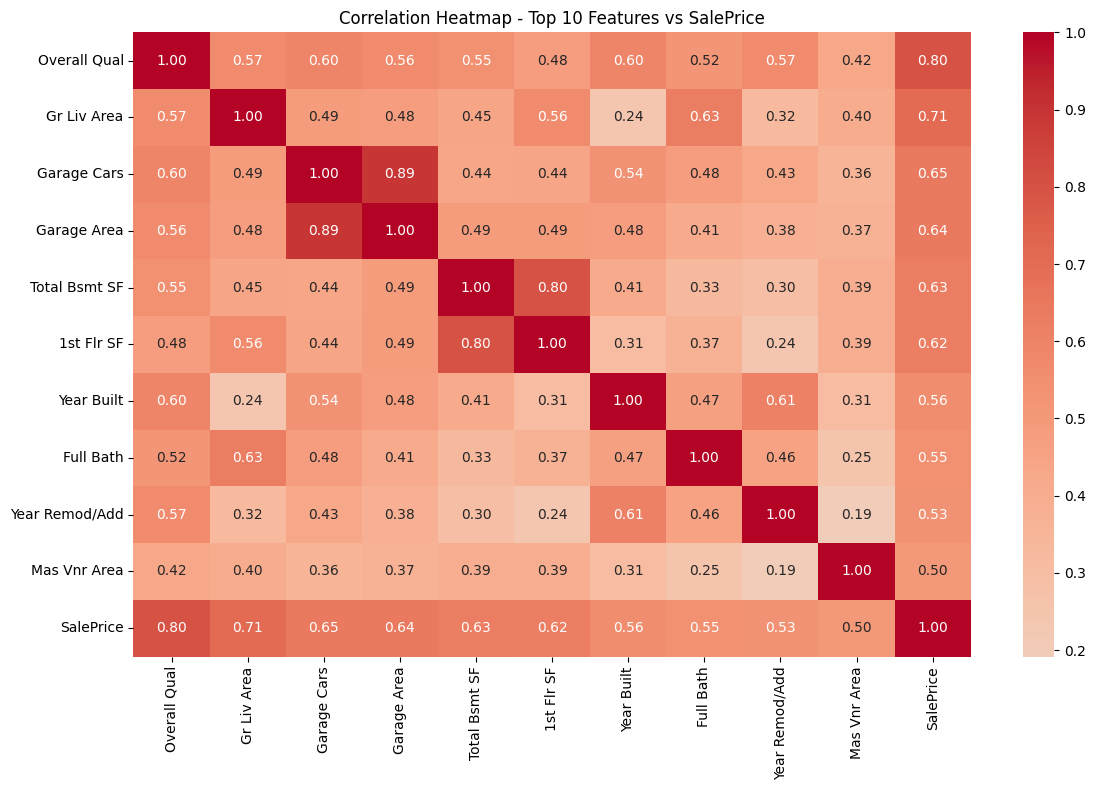

In [6]:
top_features = corr.abs().sort_values(ascending=False).head(10).index.tolist() + ['SalePrice']

plt.figure(figsize=(12, 8))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Top 10 Features vs SalePrice')
plt.tight_layout()
plt.show()

/var/folders/hx/fyjgw4xx2rx8g6gqf1mwyzlc0000gn/T/ipykernel_54111/3668587947.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/var/folders/hx/fyjgw4xx2rx8g6gqf1mwyzlc0000gn/T/ipykernel_54111/3668587947.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Overall Qual', y='SalePrice', ax=axes[1], palette='RdYlGn')


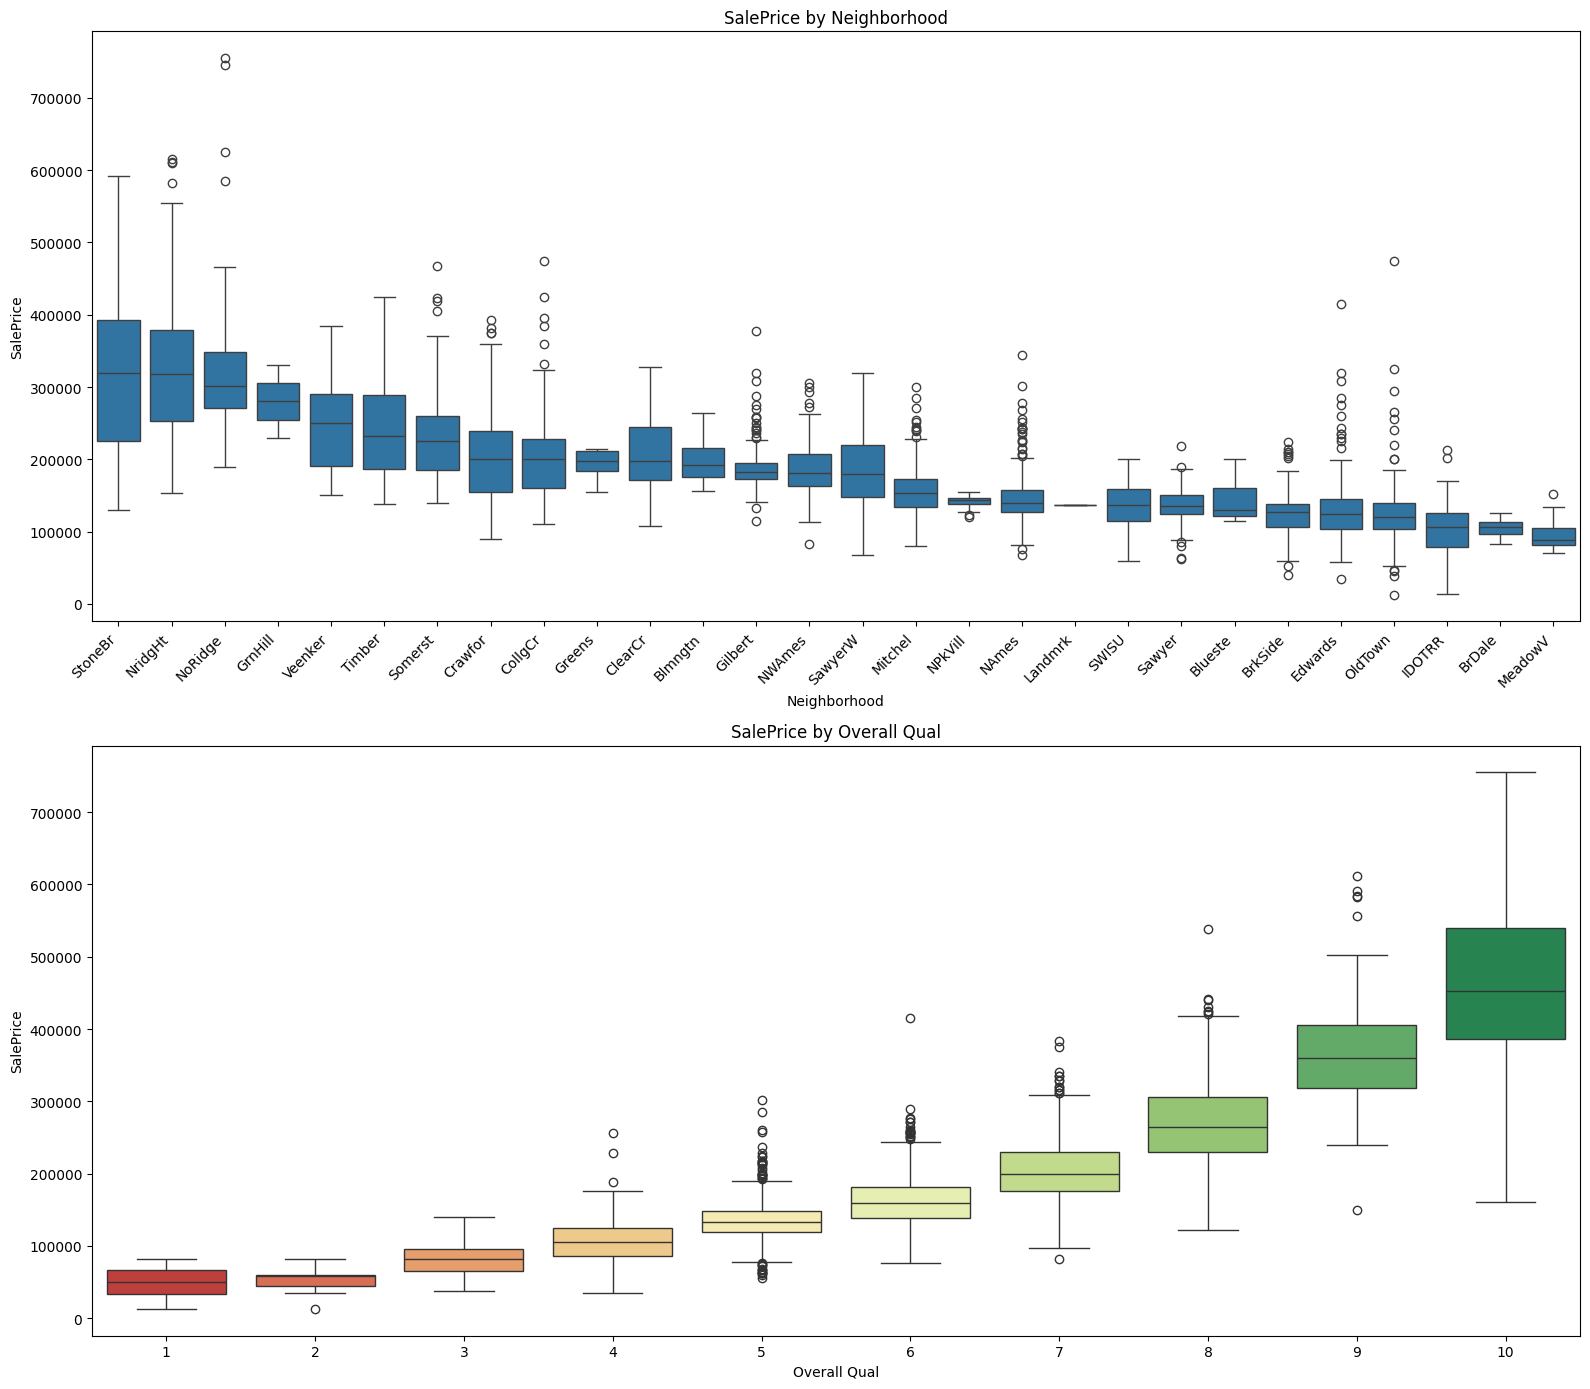

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# Neighborhood vs SalePrice
neighborhood_order = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index

sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=neighborhood_order, ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_title('SalePrice by Neighborhood')

# Overall Qual vs SalePrice
sns.boxplot(data=df, x='Overall Qual', y='SalePrice', ax=axes[1], palette='RdYlGn')
axes[1].set_title('SalePrice by Overall Qual')

plt.tight_layout()
plt.show()

In [8]:
# Summary stats
print("Neighborhood median SalePrice:")
print(df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False))
print()
print("Overall Qual median SalePrice:")
print(df.groupby('Overall Qual')['SalePrice'].median().sort_values(ascending=False))

Neighborhood median SalePrice:
Neighborhood
StoneBr    319000.0
NridgHt    317750.0
NoRidge    302000.0
GrnHill    280000.0
Veenker    250250.0
Timber     232106.5
Somerst    225500.0
Crawfor    200624.0
CollgCr    200000.0
Greens     198000.0
ClearCr    197500.0
Blmngtn    191500.0
Gilbert    183000.0
NWAmes     181000.0
SawyerW    180000.0
Mitchel    153500.0
NPkVill    143750.0
NAmes      140000.0
Landmrk    137000.0
SWISU      136200.0
Sawyer     135000.0
Blueste    130500.0
BrkSide    126750.0
Edwards    125000.0
OldTown    119900.0
IDOTRR     106500.0
BrDale     106000.0
MeadowV     88250.0
Name: SalePrice, dtype: float64

Overall Qual median SalePrice:
Overall Qual
10    451950.0
9     360000.0
8     264530.5
7     200000.0
6     159500.0
5     133000.0
4     105000.0
3      81200.0
2      57625.0
1      50150.0
Name: SalePrice, dtype: float64


In [9]:
df['Neighborhood'].value_counts().tail(10)

Neighborhood
ClearCr    44
MeadowV    37
BrDale     30
Blmngtn    28
Veenker    24
NPkVill    23
Blueste    10
Greens      8
GrnHill     2
Landmrk     1
Name: count, dtype: int64

In [10]:
neighborhood_medians = df.groupby('Neighborhood')['SalePrice'].median()

df['Neighborhood_Tier'] = df['Neighborhood'].map(
    pd.qcut(neighborhood_medians, q=3, labels=[3, 2, 1]).to_dict()
)

print(df.groupby('Neighborhood_Tier')['SalePrice'].median())

Neighborhood_Tier
1    230000.0
2    161000.0
3    124000.0
Name: SalePrice, dtype: float64


In [11]:
numeric_cols = df.select_dtypes(include='number').columns.drop('SalePrice')
skewness = df[numeric_cols].skew().sort_values(ascending=False)
print(skewness[skewness.abs() > 0.75])  # commonly used threshold

Misc Val           21.999788
Pool Area          16.939142
Lot Area           12.820898
Low Qual Fin SF    12.118162
3Ssn Porch         11.403795
Kitchen AbvGr       4.313825
BsmtFin SF 2        4.140794
Enclosed Porch      4.014446
Screen Porch        3.957467
Bsmt Half Bath      3.942389
Mas Vnr Area        2.619305
Open Porch SF       2.535386
Wood Deck SF        1.842678
1st Flr SF          1.469429
Lot Frontage        1.432805
BsmtFin SF 1        1.416421
MS SubClass         1.357579
Gr Liv Area         1.274110
Total Bsmt SF       1.150846
Bsmt Unf SF         0.923045
2nd Flr SF          0.866457
TotRms AbvGrd       0.753543
Garage Yr Blt      -3.946757
dtype: float64


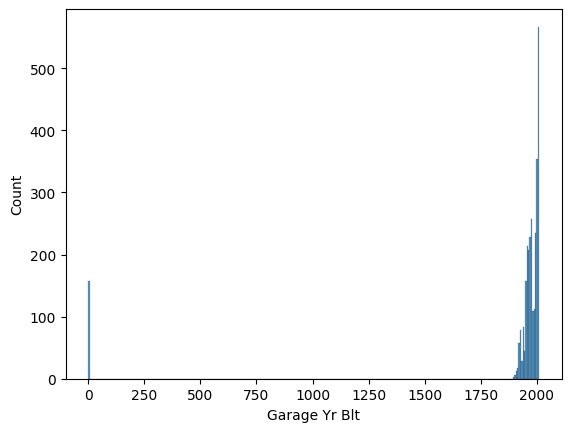

In [12]:
df['Garage Yr Blt'].value_counts().sort_index().tail(20)
sns.histplot(df['Garage Yr Blt'].dropna())
plt.show()

In [13]:
zero_inflated = ['Misc Val', 'Pool Area', 'Low Qual Fin SF', '3Ssn Porch', 
                 'BsmtFin SF 2', 'Enclosed Porch', 'Screen Porch', 'Open Porch SF', 
                 'Wood Deck SF']

# % of zeros and correlation with SalePrice
summary = pd.DataFrame({
    'pct_zero': [(df[col] == 0).mean() for col in zero_inflated],
    'corr_with_price': [df[col].corr(df['SalePrice']) for col in zero_inflated]
}, index=zero_inflated).sort_values('pct_zero', ascending=False)

print(summary)

                 pct_zero  corr_with_price
Pool Area        0.995563         0.068403
3Ssn Porch       0.987372         0.032225
Low Qual Fin SF  0.986348        -0.037660
Misc Val         0.964846        -0.015691
Screen Porch     0.912628         0.112151
BsmtFin SF 2     0.880205         0.006018
Enclosed Porch   0.843345        -0.128787
Wood Deck SF     0.520819         0.327143
Open Porch SF    0.443686         0.312951
